In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
reconc_df = pd.read_csv("data/output/reconciled.csv") # importing reconciled data

In [3]:
reconc_df.head() # getting the top of the data

,market,commodity,price_type,fews_date,wfp_date,fews_price,wfp_price,fews_unit,wfp_unit,fews_price_per_kg,wfp_price_per_kg,delta_pct,status
0,giwa,rice (milled),Retail,2012-05-02,NaN,106.66,NaN,kg,NaN,106.66,NaN,NaN,GAP
1,giwa,rice (milled),Retail,2012-05-09,NaN,106.66,NaN,kg,NaN,106.66,NaN,NaN,GAP
2,giwa,rice (milled),Retail,2012-05-16,NaN,106.66,NaN,kg,NaN,106.66,NaN,NaN,GAP
3,giwa,rice (milled),Retail,2012-05-23,NaN,106.66,NaN,kg,NaN,106.66,NaN,NaN,GAP
4,giwa,rice (milled),Retail,2012-05-30,NaN,106.66,NaN,kg,NaN,106.66,NaN,NaN,GAP


In [4]:
reconc_count = reconc_df['status'].count() # getting the total number of column in the status column

In [5]:
reconc_count

367971

In [6]:
status_count = reconc_df['status'].value_counts() # getting the value count of each values or feature in status column

In [7]:
status_count

status
MATCH       211780
GAP         123314
CONFLICT     32877
Name: count, dtype: int64

In [8]:
status_pencent_rate =  (status_count/ reconc_count) *100 # getting the precentage of the status count to thet overall values in status column

In [9]:
status_pencent_rate

status
MATCH       57.553449
GAP         33.511880
CONFLICT     8.934671
Name: count, dtype: float64

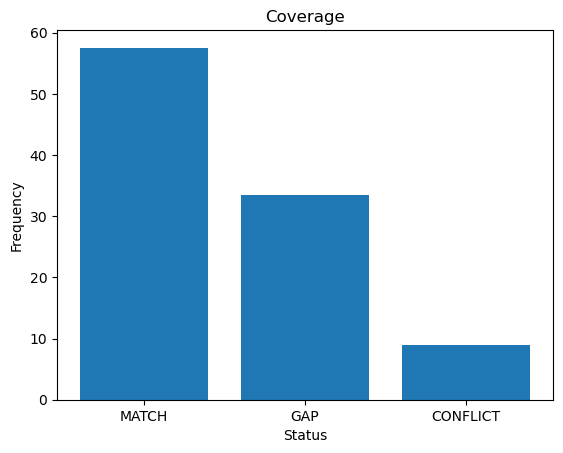

In [10]:
plt.bar(status_pencent_rate.index, status_pencent_rate.values)
plt.title('Coverage')
plt.xlabel('Status') # plotting the percentage using a bar plot
plt.ylabel('Frequency')
plt.show()

In [11]:
status_by_commodity = reconc_df.groupby(['commodity', 'status']).size().unstack(fill_value=0) # grouping the commodity based on the status count

In [12]:
status_by_commodity

status,CONFLICT,GAP,MATCH
commodity,,,
bread,707,1917,11135
cowpeas (brown),2480,8406,13191
cowpeas (white),1924,9076,15404
diesel,706,1923,10914
gari (white),3724,7825,12847
gari (yellow),3260,6957,11123
gasoline,787,1922,10873
groundnuts (shelled),1090,6857,15982
maize (white),1523,8856,16684


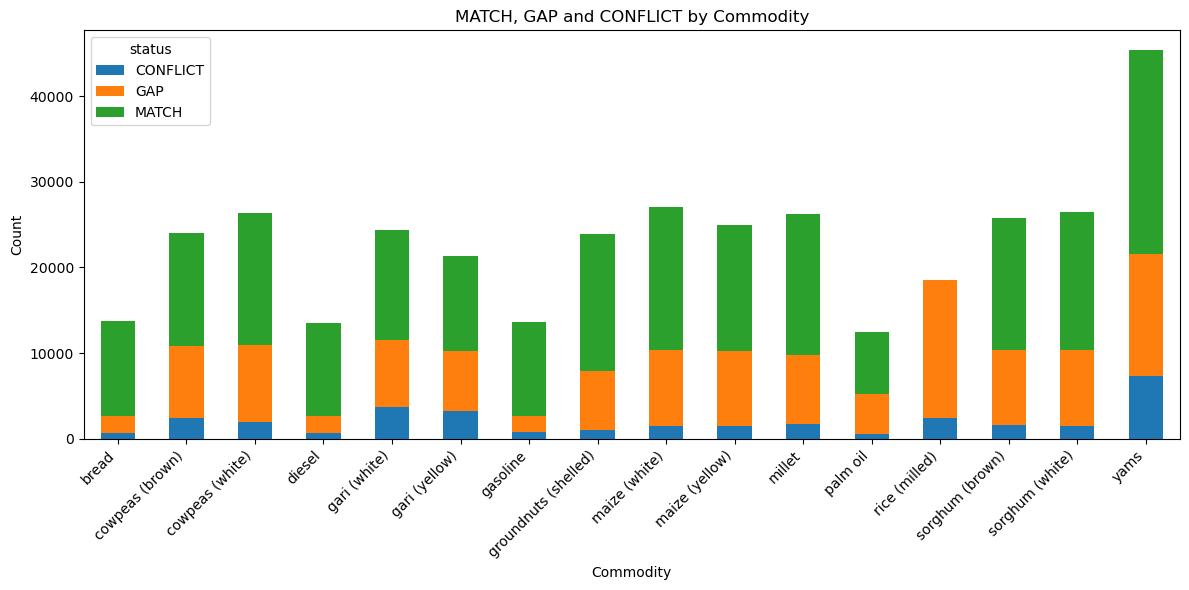

In [13]:
status_by_commodity.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('MATCH, GAP and CONFLICT by Commodity')
plt.ylabel('Count') # plotting the status per commodity using a stacked plot
plt.xlabel('Commodity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
conflict_rate = (status_by_commodity['CONFLICT'] / 
                 status_by_commodity.sum(axis=1) * 100).round(2).sort_values(ascending=False)

print(conflict_rate) # getting the percentage of the commodity in confict (in the status_value_count)

commodity
yams                    16.09
gari (yellow)           15.28
gari (white)            15.26
rice (milled)           13.11
cowpeas (brown)         10.30
cowpeas (white)          7.29
millet                   6.50
maize (yellow)           6.17
sorghum (brown)          6.08
sorghum (white)          5.86
gasoline                 5.79
maize (white)            5.63
diesel                   5.21
bread                    5.14
palm oil                 4.61
groundnuts (shelled)     4.56
dtype: float64


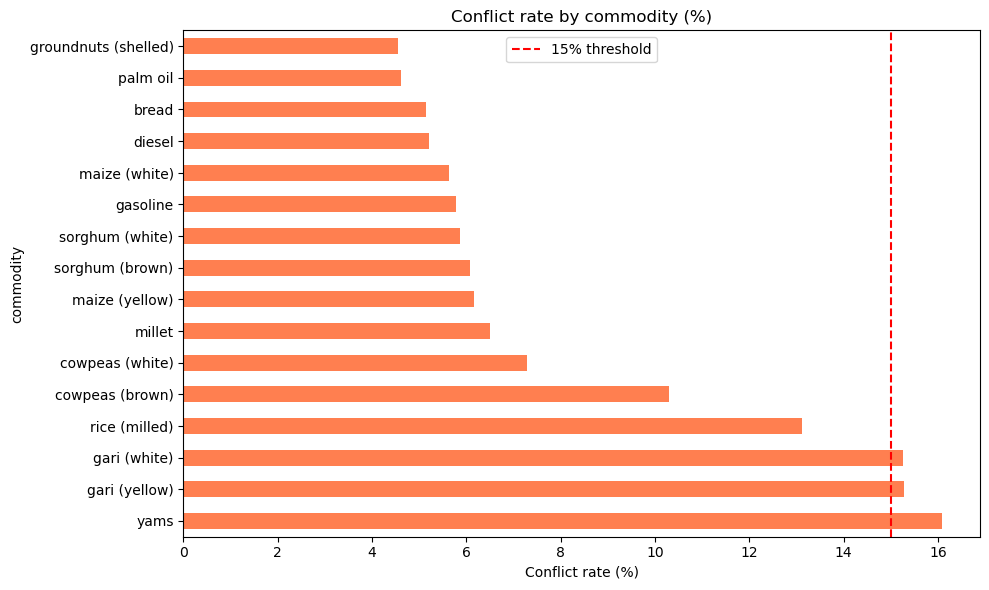

In [15]:
conflict_rate.plot(kind='barh', figsize=(10, 6), color='coral')
plt.title('Conflict rate by commodity (%)')
plt.xlabel('Conflict rate (%)')  # plotiing the conflict data in status 
plt.axvline(x=15, color='red', linestyle='--', label='15% threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Extract year-month from fews_date
reconc_df['year_month'] = pd.to_datetime(reconc_df['fews_date']).dt.to_period('M')

# Calculate monthly conflict rate
monthly_conflict = reconc_df.groupby('year_month')['status'].apply(
    lambda x: (x == 'CONFLICT').sum() / len(x) * 100
).round(2)

print(monthly_conflict.tail(20))

year_month
2023-02    12.45
2023-03     1.24
2023-04     1.50
2023-05     1.41
2023-06     0.98
2023-07     0.33
2023-08     0.39
2023-09     0.95
2023-10     1.06
2023-11     0.21
2023-12     0.37
2024-01     1.01
2024-02     1.25
2024-03     0.84
2024-04     1.03
2024-05     0.98
2024-06     1.35
2024-07     1.28
2024-08     0.84
2024-09     1.35
Freq: M, Name: status, dtype: float64


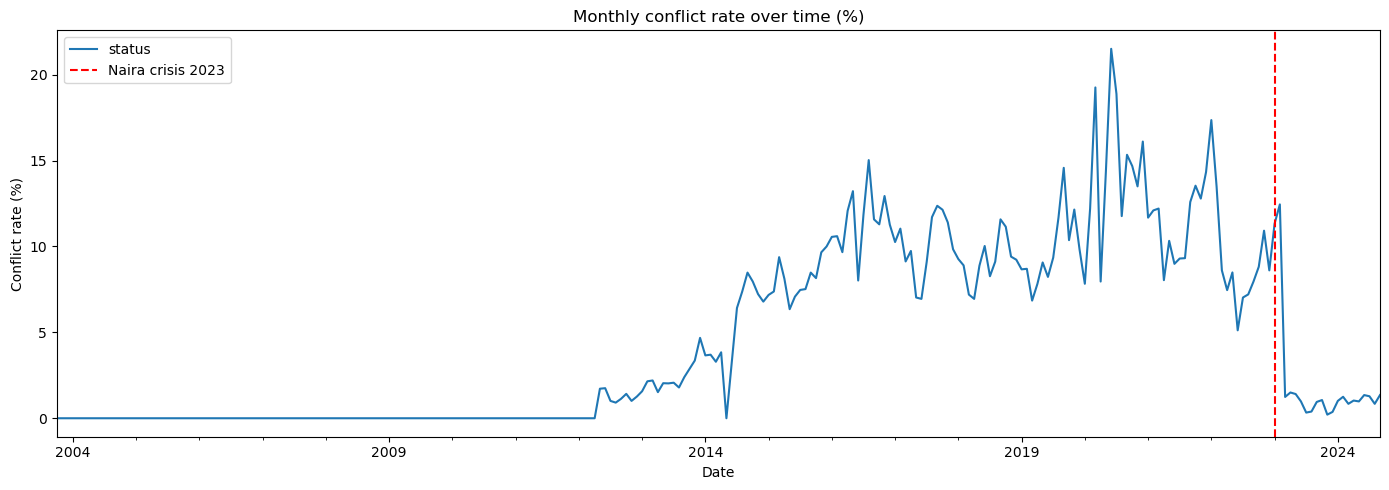

In [17]:
monthly_conflict.plot(figsize=(14, 5))
plt.title('Monthly conflict rate over time (%)')
plt.ylabel('Conflict rate (%)')
plt.xlabel('Date')
plt.axvline(x=pd.Period('2023-01', 'M'), color='red', linestyle='--', label='Naira crisis 2023')
plt.legend()
plt.tight_layout()
plt.show() #   Visualizes the temporal trend of inter-agency data conflicts, explicitly 
#   testing the hypothesis that macroeconomic shocks degrade tracking integrity

In [24]:
status_by_market = reconc_df.groupby(['market', 'status']).size().unstack(fill_value=0)
 # grouping the market based on the status count

In [25]:
status_by_market

status,CONFLICT,GAP,MATCH
market,,,
aba,479,7315,7377
biu,3527,5637,12829
damaturu,1718,5621,15377
dandume,1703,6939,14770
giwa,2315,6753,14031
gombe,1036,8994,17250
gujungu,1438,6592,15317
gwandu,1470,7171,16686
ibadan,4156,8148,14100


In [26]:
# Calculate conflict rate per market
market_conflict_rate = (status_by_market['CONFLICT'] / 
                        status_by_market.sum(axis=1) * 100).round(2).sort_values(ascending=False)



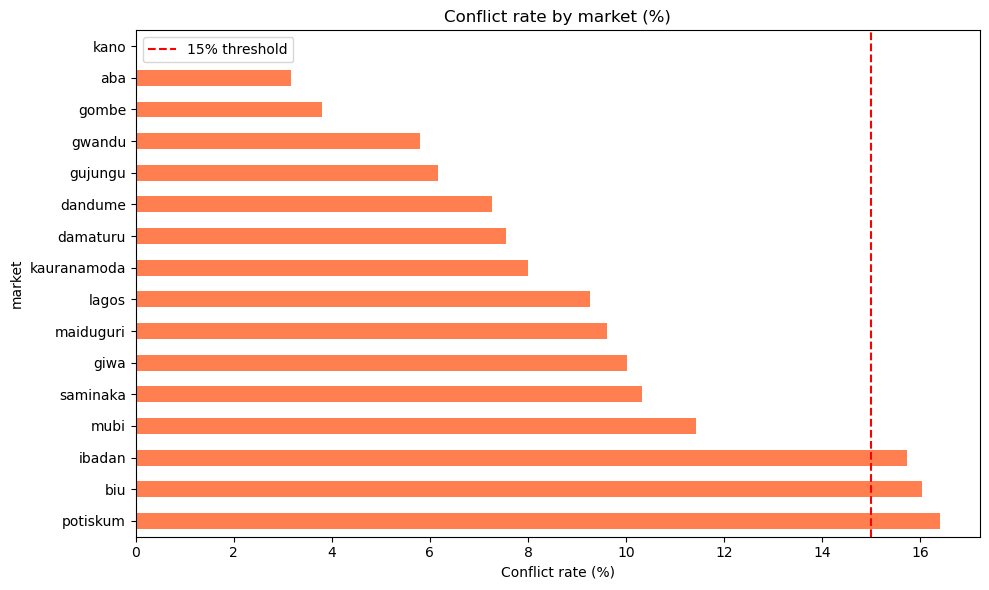

In [27]:
# Plot
market_conflict_rate.plot(kind='barh', figsize=(10, 6), color='coral')
plt.title('Conflict rate by market (%)')
plt.xlabel('Conflict rate (%)')
plt.axvline(x=15, color='red', linestyle='--', label='15% threshold')
plt.legend()
plt.tight_layout()
plt.show()

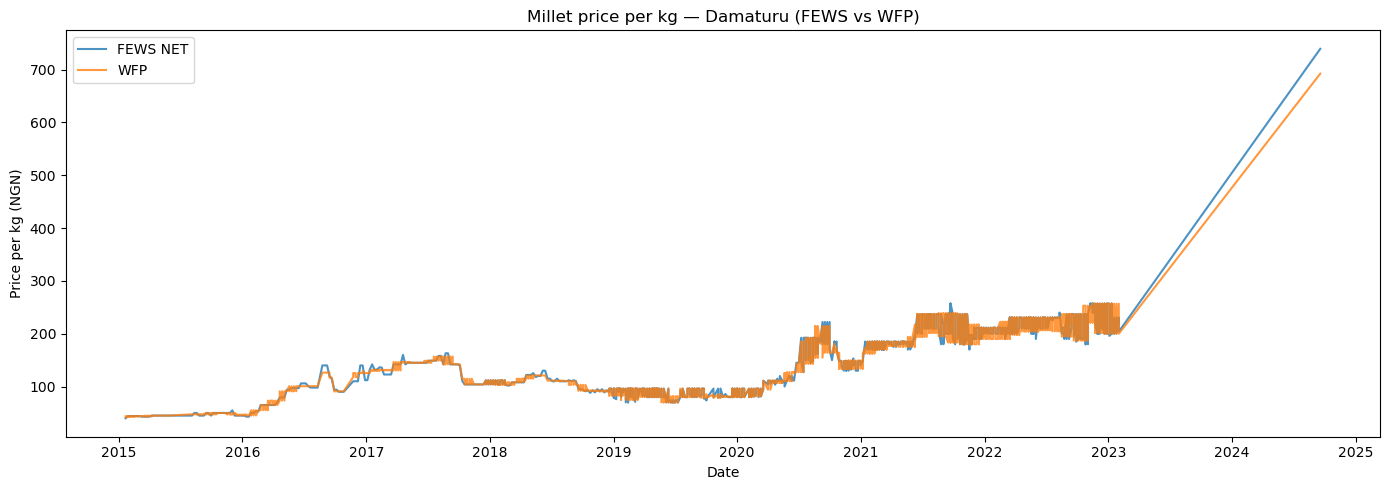

In [35]:
#   Isolates a single commodity (Millet) within a key trade hub (Damaturu) 
#   to observe micro-level divergence behaviors between FEWS NET and WFP

millet_damaturu = millet[millet['market'] == 'damaturu'].copy()
millet_damaturu = millet_damaturu.sort_values('fews_date')

plt.figure(figsize=(14, 5))
plt.plot(millet_damaturu['fews_date'], millet_damaturu['fews_price_per_kg'], label='FEWS NET', alpha=0.8)
plt.plot(millet_damaturu['fews_date'], millet_damaturu['wfp_price_per_kg'], label='WFP', alpha=0.8)
plt.title('Millet price per kg — Damaturu (FEWS vs WFP)')
plt.ylabel('Price per kg (NGN)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()